> [!Warning] 
> **This project is still in an early phase of development.**
>
> The [python API](../api.html) is not yet stable, and some aspects of the schema for the [blueprint](../terminology.html#term-blueprint) will likely evolve. 
> Therefore whilst you are welcome to try out using the package, we cannot yet guarantee backwards compatibility. 
We expect to reach a more stable version in Q1 2025.
>
> To see which systems C-Star has been tested on so far, see [Supported Systems](../machines.html).

# Importing & running a `Simulation` from a blueprint


## Contents
1. [Introduction](#1.-Introduction)
2. [Importing the Simulation](#2.-Importing-the-Simulation)
3. [Setting up the Simulation](#3.-Setting-up-the-Simulation)
4. [Compiling the Simulation and performing pre-processing](#4.-Compiling-the-Simulation-and-performing-pre-processing)
5. [Running the Simulation](#5.-Running-the-Simulation)
6. [Post-processing](#6.-Post\-processing)
7. [A quick look at the output](#7.-A-quick-look-at-the-output)
8. [Summary](#8.-Summary)

## 1. Introduction 
[(return to top)](#Contents)

On this page, we will import and execute a ROMS-MARBL [Simulation](../terminology.html#term-Simulation) (constructed and exported on [the previous page](../tutorials/1_building_a_simulation_and_exporting_it_as_a_blueprint.html)) using C-Star. In particular, we will:

- Create a Simulation from a pre-prepared [blueprint](../terminology.html#term-blueprint) (`ROMSSimulation.from_blueprint()`). See  for more information on blueprints and how to create them.
- Set up the simulation locally (`ROMSSimulation.setup()`)
- Compile any necessary code associated with the simulation (`ROMSSimulation.build()`)
- Complete any pre-processing steps associated with the simulation (`ROMSSimulation.pre_run()`)
- Run the case with a small time step for a couple of simulation (`ROMSSimulation.run()`)
- Execute any post-processing steps associated with the simulation (`ROMSSimulation.post_run()`)

## 2. Importing the `Simulation` 
[(return to top)](#Contents)

We can construct a `ROMSSimulation` from a blueprint using the `ROMSSimulation.from_blueprint` method. The case we'll be looking at in this example is a January 2012 simulation of ocean physics and biogeochemistry around the Welsh coast, small enough to run on a laptop.

In [1]:
from pathlib import Path
from cstar.roms import ROMSSimulation

output_path = Path("../../examples/outputs")

example_simulation_1 = ROMSSimulation.from_blueprint(
    # this can be a local path or URL to your blueprint
    blueprint=output_path / "blueprint_example/roms_marbl_example.yaml",
    # where you would like to setup and run the simulation
    directory=output_path / "roms_marbl_example",
    # the dates between which you would like to run the Simulation
    start_date="2012-01-01 12:00:00",
    end_date="2012-01-03 12:00:00",
)

The arguments are:
- `blueprint`: the local path or URL to your blueprint file
- `directory` : where you would like C-Star to assemble and run your `Simulation`
- `start_` and `end_date` : the dates you would like to run the simulation. An error will be raised if these dates fall outside the valid date range supported by the blueprint.

As a reminder, here's an overview of the `Simulation` we just created from our blueprint. For a complete deconstruction of the `Simulation`, see the [the previous page](../tutorials/1_building_a_simulation_and_exporting_it_as_a_blueprint.html):

In [2]:
print(example_simulation_1)

Retrieving URL for remote in repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieved URL for remote in repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieving commit hash for repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieved commit hash for repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieving remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.
Retrieved remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.
Retrieving URL for remote in repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieved URL for remote in repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieving commit hash for repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieved commit hash for repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieving remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
Retrieved remote refs for repository

In [3]:
print(example_simulation_1.tree())

/Users/chris/code/cstar/examples/outputs/roms_marbl_example
└── ROMS
    ├── input_datasets
    │   ├── roms_grd.nc
    │   ├── roms_ini.nc
    │   ├── roms_tides.nc
    │   ├── roms_riv_frc.nc
    │   ├── roms_bry.nc
    │   ├── roms_bry_bgc.nc
    │   ├── roms_frc.nc
    │   └── roms_frc_bgc.nc
    ├── runtime_code
    │   ├── roms.in_TEMPLATE
    │   ├── marbl_in
    │   ├── marbl_tracer_output_list
    │   └── marbl_diagnostic_output_list
    └── compile_time_code
        ├── bgc.opt
        ├── bulk_frc.opt
        ├── cppdefs.opt
        ├── diagnostics.opt
        ├── ocean_vars.opt
        ├── param.opt
        ├── tracers.opt
        ├── river_frc.opt
        ├── Makefile
        └── Make.depend



<div class="alert alert-info">

Note

Nothing we have seen above represents anything local on our machine (yet). Each object simply describes where various files may be found, and the `ROMSSimulation.tree()` representation shows us where these files will be assembled once we set everything up. To turn that into something concrete we can work with, we call `ROMSSimulation.setup()`.

</div>

## 3. Setting up the `Simulation`
[(return to top)](#Contents)

Next we call `ROMSSimulation.setup()`. This will:

- Fetch and compile any external codebases (ROMS and MARBL)
- Fetch any remote data associated with this case
- Construct any ROMS netCDF files from yaml files using `roms-tools` 

We will be prompted before installing the base models, so some input is required here:

In [4]:
example_simulation_1.setup()

2025-04-16 14:51:30,290 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1094: Configuring ROMSSimulation
--------------------------
2025-04-16 14:51:30,291 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1095: Setting up ROMSExternalCodeBase...


Retrieving URL for remote in repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieved URL for remote in repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieving commit hash for repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieved commit hash for repository `/Users/chris/code/cstar/cstar/externals/ucla-roms`.
Retrieving remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.


2025-04-16 14:51:30,572 | INFO | cstar.roms.external_codebase.ROMSExternalCodeBase::handle_config_status:232: ROMSExternalCodeBase correctly configured. Nothing to be done
2025-04-16 14:51:30,573 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1099: Setting up MARBLExternalCodeBase...


Retrieved remote refs for repository `https://github.com/CESR-lab/ucla-roms.git`.
Retrieving URL for remote in repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieved URL for remote in repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieving commit hash for repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieved commit hash for repository `/Users/chris/code/cstar/cstar/externals/MARBL`.
Retrieving remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.


2025-04-16 14:51:30,912 | INFO | cstar.marbl.external_codebase.MARBLExternalCodeBase::handle_config_status:232: MARBLExternalCodeBase correctly configured. Nothing to be done
2025-04-16 14:51:30,913 | INFO | cstar.roms.simulation.ROMSSimulation::setup:1103: 
Fetching compile-time code code...
----------------------------------


Retrieved remote refs for repository `https://github.com/marbl-ecosys/MARBL.git`.
Cloning `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git`


2025-04-16 14:51:31,744 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying bgc.opt to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code
2025-04-16 14:51:31,745 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying bulk_frc.opt to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code
2025-04-16 14:51:31,746 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying cppdefs.opt to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code
2025-04-16 14:51:31,746 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying diagnostics.opt to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code
2025-04-16 14:51:31,747 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying ocean_vars.opt to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code
2025-04-16 14:51:31,747 | INFO | cstar.ba

Cloned https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git to /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpnh00ens6
Checking out `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git` @ `main`
Checked out main in git repository /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpnh00ens6
Cloning `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git`


2025-04-16 14:51:32,474 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying roms.in_TEMPLATE to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/runtime_code
2025-04-16 14:51:32,475 | INFO | cstar.base.additional_code.AdditionalCode::get:222: Copying template file /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/runtime_code/roms.in_TEMPLATE to editable version /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/runtime_code/roms.in
2025-04-16 14:51:32,476 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_in to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/runtime_code
2025-04-16 14:51:32,476 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_tracer_output_list to /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/runtime_code
2025-04-16 14:51:32,477 | INFO | cstar.base.additional_code.AdditionalCode::get:209: Copying marbl_diagnostic_output_li

Cloned https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git to /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpa50x59v2
Checking out `https://github.com/CWorthy-ocean/cstar_blueprint_roms_marbl_example.git` @ `main`
Checked out main in git repository /var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/tmpa50x59v2


## 4. Compiling the `Simulation` and performing pre-processing
[(return to top)](#Contents)

We have now assembled all the data we need to run this `Simulation` in one place. Lastly, we need to compile the additional code we've obtained and run some pre-processing steps on the input data:

In [5]:
# the Simulation.build() method compiles the code
example_simulation_1.build()

Compiling UCLA-ROMS configuration...
UCLA-ROMS compiled at /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/compile_time_code


In [6]:
# the Simulation.pre_run() method performs pre-processing
example_simulation_1.pre_run()

2025-04-16 14:51:47,718 | INFO | cstar.roms.input_dataset.ROMSModelGrid::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/input_datasets/roms_grd.nc into (3,3)
2025-04-16 14:51:47,870 | INFO | cstar.roms.input_dataset.ROMSInitialConditions::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/input_datasets/roms_ini.nc into (3,3)
/opt/anaconda3/envs/cstar/lib/python3.13/site-packages/roms_tools/tiling/partition.py:322: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath.with_suffix(".nc"))
2025-04-16 14:51:48,086 | INFO | cstar.roms.input_dataset.ROMSTidalForcing::partition:108: Partitioning /Users/chris/code/cstar/examples/outputs/roms_marbl_example/ROMS/input_datasets/roms_tides.nc into (3,3)
2025-04-16 14:51:48,127 | INFO | c

## 5. Running the `Simulation`

[(return to top)](#Contents)

In [7]:
simulation_run = example_simulation_1.run()

<div class="alert alert-info">

Note

Here we call `ROMSSimulation.run()` without arguments under the assumption we are running this (small) simulation locally, on a personal computer.

- For more information on local process runs, see this [how-to guide](../howto_guides/4_running_on_personal_computers.html).
- For information on running on a supported supercomputing system, see [the corresponding doc page](../howto_guides/5_handling_jobs_on_hpc_systems.ipynb).

</div>

We can track the status of the submitted job using [LocalProcess.status](../generated/cstar.execution.local_process.LocalProcess.html#cstar.execution.local_process.LocalProcess.status). It will change from:

In [8]:
simulation_run.status

<ExecutionStatus.RUNNING: 3>

(while executing) to:

In [9]:
simulation_run.status

<ExecutionStatus.RUNNING: 3>

(when finished). 

## 6. Post-processing

[(return to top)](#Contents)

Once the run is complete, we can carry out any post-processing steps.
When ROMS runs on multiple CPUs in parallel, it produces one output file per CPU. To work with the output, we thus need to join these files together. This is handled with the `post_run()` method:

In [10]:
from cstar.execution.handler import ExecutionStatus

# Use the handler to request status updates on the simulation
simulation_run.updates(0, confirm_indefinite=True)

if simulation_run.status != ExecutionStatus.RUNNING:
    print(simulation_run.status)

if simulation_run.status == ExecutionStatus.FAILED:
    print("An error occurred. See:", simulation_run.output_file)
else:
    example_simulation_1.post_run()

2025-04-16 14:51:51,451 | INFO | cstar.execution.local_process.LocalProcess::updates:168:      53 4383.5368 5.16575553432-03 4.5734631956-03  0.005128622245  0.004217126455     11     27   12

2025-04-16 14:51:51,452 | INFO | cstar.execution.local_process.LocalProcess::updates:168:  doing BGC with MARBL

2025-04-16 14:51:51,452 | INFO | cstar.execution.local_process.LocalProcess::updates:168:      54 4383.5375 5.16262205183-03 4.5676659151-03  0.005175696196  0.004227880927     11     27   12

2025-04-16 14:51:51,452 | INFO | cstar.execution.local_process.LocalProcess::updates:168:  doing BGC with MARBL

2025-04-16 14:51:51,453 | INFO | cstar.execution.local_process.LocalProcess::updates:168:      55 4383.5381 5.15976713410-03 4.5621716843-03  0.005220217034  0.004237037762     11     27   12

2025-04-16 14:51:51,453 | INFO | cstar.execution.local_process.LocalProcess::updates:168:  doing BGC with MARBL

2025-04-16 14:51:51,454 | INFO | cstar.execution.local_process.LocalProcess::updat

completed
Joining netCDF files ROMS_MARBL_bgc.20120101120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120103120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_rst.20120102120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_his.20120101120000.*.nc...
Command completed successfully.
Joining netCDF files ROMS_MARBL_bgc_dia.20120101120000.*.nc...
Command completed successfully.


## 7. A quick look at the output

[(return to top)](#Contents)

In the above post-processing step, we can see that the ROMS run produced several "restart" files (`ROMS_MARBL_rst.*`) that can be used by ROMS to restart the run.
On the [next page](../tutorials/3_restarting_and_continuing_a_simulation.html), we will use C-Star to restart and continue our Case, and C-Star will find and use these files to do so.

For now, let's produce a plot comparing the initial condition we started with with the final restart file (which will serve as the initial condition on the [next page](../tutorials/3_restarting_and_continuing_a_simulation.html)).

C-Star doesn't currently support plots of model data, so we will have to manually produce these using the model files. Don't worry too much about understanding the model's naming conventions in this code cell (C-Star will usually take care of these things for you) - this is just a visual demonstration!

In [11]:
%matplotlib inline

/var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/ipykernel_58651/1248095220.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ini_ds = xr.open_dataset(simulation_path / "ROMS/input_datasets/roms_ini.nc")
/var/folders/pj/bk3042bs0tldhwq8htgfnm640000gn/T/ipykernel_58651/1248095220.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


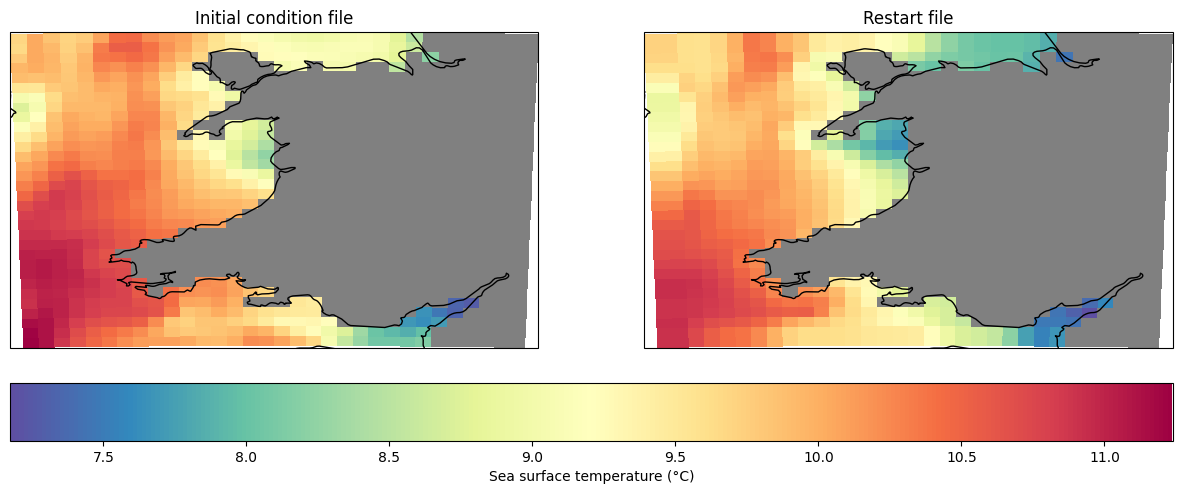

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

simulation_path = example_simulation_1.directory

# The ROMS grid file for latitude & longitude data
grd_ds = xr.open_dataset(simulation_path / "ROMS/input_datasets/roms_grd.nc")
# The initial condition file
ini_ds = xr.open_dataset(simulation_path / "ROMS/input_datasets/roms_ini.nc")
# The restart file
rst_ds = xr.open_dataset(simulation_path / "output/ROMS_MARBL_rst.20120103120000.nc")

var = "temp"
ini_data = ini_ds[var].where(grd_ds.mask_rho).isel(s_rho=-1, ocean_time=0)
rst_data = rst_ds[var].where(grd_ds.mask_rho).isel(s_rho=-1, time=0)

# Create figure and axes
fig, ax = plt.subplots(
    1, 2, subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(15, 9)
)

# Plot the data
cmap = plt.get_cmap("Spectral_r")
cmap.set_bad("gray")
vmin = min(ini_data.where(grd_ds.mask_rho).min(), rst_data.where(grd_ds.mask_rho).min())
vmax = max(ini_data.where(grd_ds.mask_rho).max(), rst_data.where(grd_ds.mask_rho).max())
kwargs = {"cmap": cmap, "vmin": vmin, "vmax": vmax}
p0 = ax[0].pcolormesh(
    grd_ds.lon_rho, grd_ds.lat_rho, ini_data, transform=ccrs.PlateCarree(), **kwargs
)
p1 = ax[1].pcolormesh(
    grd_ds.lon_rho, grd_ds.lat_rho, rst_data, transform=ccrs.PlateCarree(), **kwargs
)

# Add coastlines and land mask
[a.add_feature(cfeature.COASTLINE, linewidth=1) for a in ax]

# Add a colorbar
ax[0].set_title("Initial condition file")
ax[1].set_title("Restart file")
plt.colorbar(
    p1, ax=ax, orientation="horizontal", pad=0.05, label="Sea surface temperature (°C)"
)
fig.show()
grd_ds.close()


## 8. Summary
[return to top](#Contents)

On this page we:

- Created a C-Star `Simulation` from a "blueprint" file
- Ran the case for 2 days from 2012-01-01 to 2012-01-03 with a 1 minute time-step
- Produced a basic plot to verify the output

On the [next page](../tutorials/3_restarting_and_continuing_a_simulation.html) we will "restart" the `Simulation`, running it with a larger time-step for the remainder of January 2012.